## Background
This notebook prepares meta-features for the results postprocessing after two-stage Gemma 2 fine-tuning.

## Imports

In [ ]:
import warnings
import ast
import os
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import emoji
from langdetect import detect

In [ ]:
warnings.filterwarnings("ignore")

## Constants

In [ ]:
TRAIN_PATH = "../../data/"
TRAIN_NAME = "train.parquet"
TEST_NAME = "test.csv"

## Read data

In [ ]:
train = pd.read_parquet(os.path.join(TRAIN_PATH, TRAIN_NAME))
display(train.head())

test = pd.read_csv(os.path.join(TRAIN_PATH, TEST_NAME))
display(test.head())

,id,content,lang,manipulative,techniques,trigger_words
0,0bb0c7fa-101b-4583-a5f9-9d503339141c,Новий огляд мапи DeepState від російського вій...,uk,True,"[euphoria, loaded_language]","[[27, 63], [65, 88], [90, 183], [186, 308]]"
1,7159f802-6f99-4e9d-97bd-6f565a4a0fae,Недавно 95 квартал жёстко поглумился над русск...,ru,True,"[loaded_language, cherry_picking]","[[0, 40], [123, 137], [180, 251], [253, 274]]"
2,e6a427f1-211f-405f-bd8b-70798458d656,🤩\nТим часом йде евакуація Бєлгородського авто...,uk,True,"[loaded_language, euphoria]","[[55, 100]]"
3,1647a352-4cd3-40f6-bfa1-d87d42e34eea,В Україні найближчим часом мають намір посилит...,uk,False,None,None
4,9c01de00-841f-4b50-9407-104e9ffb03bf,"Расчёты 122-мм САУ 2С1 ""Гвоздика"" 132-й бригад...",ru,True,[loaded_language],"[[114, 144]]"


,id,content,techniques,trigger_words
0,521cd2e8-dd9f-42c4-98ba-c0c8890ff1ba,"Они просрали нашу технику, положили кучу людей...","['fud', 'loaded_language']","[(0, 12), (27, 46), (48, 71), (131, 162), (164..."
1,9b2a61e4-d14e-4ff7-b304-e73d720319bf,❗️\nКитай предлагает отдать оккупированные тер...,['loaded_language'],"[(374, 425)]"
2,f0f1c236-80a8-4d25-b30c-a420a39be632,Сегодня будет ровно 6 месяцев с этого обещания...,['loaded_language'],"[(0, 127)]"
3,31ea05ba-2c2b-4b84-aba7-f3cf6841b204,⚡️\nІзраїль вперше у світі збив балістичну рак...,[],NaN
4,a79e13ec-6d9a-40b5-b54c-7f4f743a7525,Склав невелику навчально-методичну таблицю на ...,['loaded_language'],"[(87, 103), (127, 136), (170, 189), (204, 255)..."


In [3]:
# Extract trigger_words phrases from the text:
trigger_words_phrases = []
for text, trigger_words in zip(train.content.values, train.trigger_words.values):
    if text is None or trigger_words is None:
        trigger_words_phrases.append([])
        continue
    trigger_words_phrases.append([text[i:j] for i, j in trigger_words])
train["trigger_words_phrases"] = trigger_words_phrases

In [4]:
from collections import Counter

unique_techniques = Counter()
for t in train["techniques"]:
    unique_techniques.update(t)

techniques_dict = {k: i for i, k in enumerate(unique_techniques.keys())}
techniques_dict

{'euphoria': 0,
 'loaded_language': 1,
 'cherry_picking': 2,
 'glittering_generalities': 3,
 'cliche': 4,
 'appeal_to_fear': 5,
 'bandwagon': 6,
 'fud': 7,
 'whataboutism': 8,
 'straw_man': 9}

## Get embeddings

In [ ]:
# Get vectors for texts:
model = SentenceTransformer('Alibaba-NLP/gte-multilingual-base', trust_remote_code=True, device="mps")

/Users/trokhymovych/Documents/GitHub/propaganda_competition/.conda/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of the model checkpoint at Alibaba-NLP/gte-multilingual-base were not used when initializing NewModel: {'classifier.bias', 'classifier.weight'}
- This IS expected if you are initializing NewModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NewModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
all_texts_to_encode = train["content"].to_list() + train["trigger_words_phrases"].apply(lambda x: ", ".join(x)).to_list() + test["content"].to_list()
all_texts_to_encode = [t[:5000] for t in all_texts_to_encode]

text_vectors_all = model.encode(all_texts_to_encode, show_progress_bar=True, normalize_embeddings=True, batch_size=8)
text_vectors = text_vectors_all[:len(train)]
triger_phrases_vectors = text_vectors_all[len(train):-len(test)]
text_vectors_test = text_vectors_all[-len(test):]

Batches: 100%|██████████| 1673/1673 [08:28<00:00,  3.29it/s]


## Construct clusters

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/trokhymovych/Documents/GitHub/propaganda_competition/.conda/lib/python3.9/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


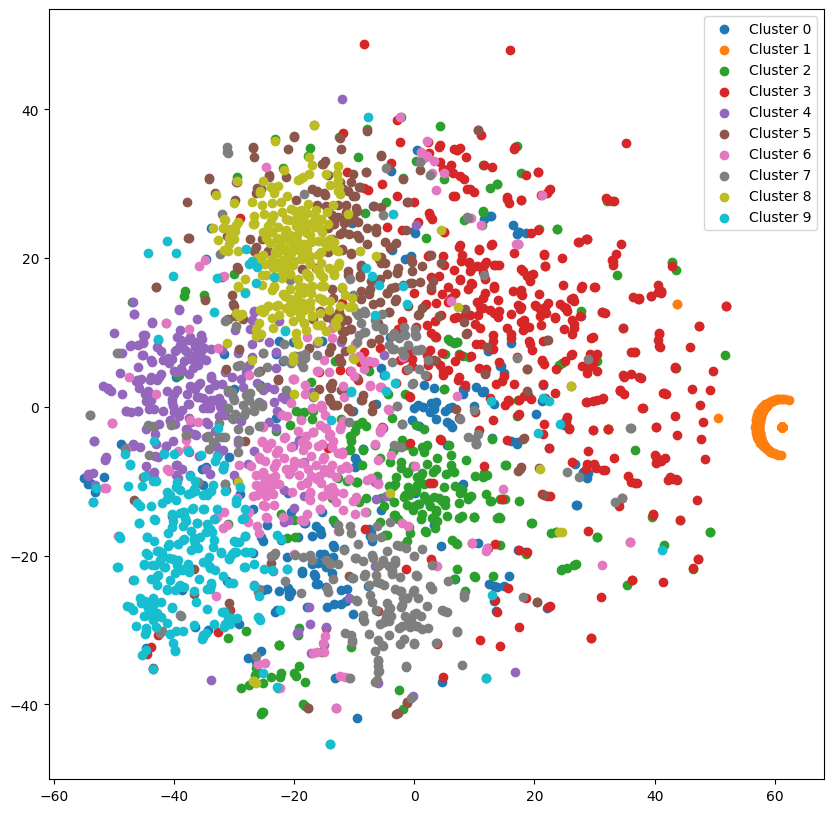

In [ ]:
# Cluster and visualize the triger_phrases_vectors:

kmeans = KMeans(n_clusters=10, random_state=0).fit(triger_phrases_vectors)
clusters = kmeans.predict(triger_phrases_vectors)

tsne = TSNE(n_components=2, random_state=0)
tsne_res = tsne.fit_transform(triger_phrases_vectors)

plt.figure(figsize=(10, 10))
for i in range(10):
    plt.scatter(tsne_res[clusters == i, 0], tsne_res[clusters == i, 1], label=f"Cluster {i}")
plt.legend()
plt.show()

# Get vectors for cluster centers:
cluster_centers = kmeans.cluster_centers_

## Get similar samples

In [ ]:
# For each sample id get 10 most similar texts and their techniques:

N = 20

sim_texts, sim_measur, sim_techniques = [], [], []
for i in tqdm(range(len(train))):
    sample_vector = text_vectors[i]
    similarities = cosine_similarity(sample_vector.reshape(1, -1), triger_phrases_vectors)[0]
    # Make sure that the sample is not in the top:
    similarities[i] = 0
    most_similar_indices = similarities.argsort()[-N:][::-1]
    sim_texts.append([train["content"].iloc[j] for j in most_similar_indices])
    sim_measur.append([similarities[j] for j in most_similar_indices])
    sim_techniques.append([train["techniques"].iloc[j] for j in most_similar_indices])

# The same but text_vectors instead of triger_phrases_vectors:
sim_texts_t, sim_measur_t, sim_techniques_t = [], [], []
for i in tqdm(range(len(train))):
    sample_vector = text_vectors[i]
    similarities = cosine_similarity(sample_vector.reshape(1, -1), text_vectors)[0]
    # Make sure that the sample is not in the top:
    similarities[i] = 0
    most_similar_indices = similarities.argsort()[-N:][::-1]
    sim_texts_t.append([train["content"].iloc[j] for j in most_similar_indices])
    sim_measur_t.append([similarities[j] for j in most_similar_indices])
    sim_techniques_t.append([train["techniques"].iloc[j] for j in most_similar_indices])

100%|██████████| 3822/3822 [00:13<00:00, 283.68it/s]


In [61]:
# for each sample make the tecniques counter:
sim_techniques_counters = []
for i in range(len(sim_techniques)):
    c = Counter()
    for t in sim_techniques[i]:
        c.update(t)
    sim_techniques_counters.append(c)

sim_techniques_counters_t = []
for i in range(len(sim_techniques_t)):
    c = Counter()
    for t in sim_techniques_t[i]:
        c.update(t)
    sim_techniques_counters_t.append(c)

# Make the vector for each sample:
sim_techniques_vectors = []
for i in range(len(sim_techniques_counters)):
    v = np.zeros(len(techniques_dict) * 2)
    for j, t in enumerate(unique_techniques):
        v[j] = sim_techniques_counters[i][t]
    for j, t in enumerate(unique_techniques):
        v[j + len(techniques_dict)] = sim_techniques_counters_t[i][t]
    sim_techniques_vectors.append(v)

# get the distance from the cluster centers (cosine similarity):
distances = []
for i in range(len(sim_techniques_vectors)):
    distances.append(cosine_similarity(text_vectors[i].reshape(1, -1), cluster_centers)[0])

# Concat the vectors and sim_techniques_vectors:
sim_techniques_vectors = np.array(sim_techniques_vectors)
sim_techniques_vectors = np.concatenate([sim_techniques_vectors, distances], axis=1)

In [64]:
sim_texts_test, sim_measur_test, sim_techniques_test = [], [], []
for i in tqdm(range(len(test))):
    sample_vector = text_vectors_test[i]
    similarities = cosine_similarity(sample_vector.reshape(1, -1), triger_phrases_vectors)[0]
    most_similar_indices = similarities.argsort()[-N:][::-1]
    sim_texts_test.append([train["content"].iloc[j] for j in most_similar_indices])
    sim_measur_test.append([similarities[j] for j in most_similar_indices])
    sim_techniques_test.append([train["techniques"].iloc[j] for j in most_similar_indices])

sim_texts_t_test, sim_measur_t_test, sim_techniques_t_test = [], [], []
for i in tqdm(range(len(test))):
    sample_vector = text_vectors_test[i]
    similarities = cosine_similarity(sample_vector.reshape(1, -1), text_vectors)[0]
    most_similar_indices = similarities.argsort()[-N:][::-1]
    sim_texts_t_test.append([train["content"].iloc[j] for j in most_similar_indices])
    sim_measur_t_test.append([similarities[j] for j in most_similar_indices])
    sim_techniques_t_test.append([train["techniques"].iloc[j] for j in most_similar_indices])

sim_techniques_counters_test = []
for i in range(len(sim_techniques_test)):
    c = Counter()
    for t in sim_techniques_test[i]:
        c.update(t)
    sim_techniques_counters_test.append(c)

sim_techniques_counters_t_test = []
for i in range(len(sim_techniques_t_test)):
    c = Counter()
    for t in sim_techniques_t_test[i]:
        c.update(t)
    sim_techniques_counters_t_test.append(c)

sim_techniques_vectors_test = []
for i in range(len(sim_techniques_counters_test)):
    v = np.zeros(len(techniques_dict) * 2)
    for j, t in enumerate(unique_techniques):
        v[j] = sim_techniques_counters_test[i][t]
    for j, t in enumerate(unique_techniques):
        v[j + len(techniques_dict)] = sim_techniques_counters_t_test[i][t]
    sim_techniques_vectors_test.append(v)

distances_test = []
for i in range(len(sim_techniques_vectors_test)):
    distances_test.append(cosine_similarity(text_vectors_test[i].reshape(1, -1), cluster_centers)[0])

sim_techniques_vectors_test = np.array(sim_techniques_vectors_test)
sim_techniques_vectors_test = np.concatenate([sim_techniques_vectors_test, distances_test], axis=1)

sim_techniques_vectors_test.shape

100%|██████████| 5735/5735 [00:20<00:00, 286.65it/s]


(5735, 30)

## Extract additional features

In [ ]:
emoji.EMOJI_DATA["⚡️"] = "trucha"

def get_text_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

features_list = [
    'lang',
    'num_words',
    'num_chars',
    'punctuations_rate',
    'caps_rate',
    'emoji_rate',
    # 'emojis_sentiment',
    'num_mentions',
    'num_urls',
    "num_question_marks",
    "num_exclamation_marks",
    "num_ellipsis",
    "num_quotes",
    "start_with_emoji",
    "first_10_is_emoji",
    "is_rainbow",
]

cat_features = []

class FeatureFactory:
    def __init__(self, features_list):
        self.features = features_list
        self.cat_features = []

    def get_lang(self, df):
        self.cat_features.append("lang")
        df["lang"] = df["content"].apply(get_text_lang).map({
            "en": 0,
            "ru": 1,
            "uk": 2,
            "unknown": 3
        })
        return df
    
    def get_num_words(self, df):
        df["num_words"] = df["content"].apply(lambda x: len(x.split()))
        return df
    
    def get_num_chars(self, df):
        df["num_chars"] = df["content"].apply(lambda x: len(x))
        return df
    
    def get_punctuations_rate(self, df):
        df["punctuations_rate"] = df["content"].apply(lambda x: len([c for c in x if c in ".,!?"]) / len(x))
        return df
    
    def get_caps_rate(self, df):    
        df["caps_rate"] = df["content"].apply(lambda x: len([c for c in x if c.isupper()]) / len(x))
        return df
    
    def get_emoji_rate(self, df):
        df["emoji_rate"] = df["content"].apply(lambda x: len([c for c in x if c in emoji.EMOJI_DATA]) / len(x))
        return df
    
    def get_emojis_sentiment(self, df):
        return df

    def get_num_mentions(self, df):
        df["num_mentions"] = df["content"].apply(lambda x: len([c for c in x if c == "@"]))
        return df
    
    def get_num_urls(self, df):
        df["num_urls"] = df["content"].apply(lambda x: len([c for c in x if c == "http"]))
        return df
    
    def get_num_question_marks(self, df):
        df["num_question_marks"] = df["content"].apply(lambda x: len([c for c in x if c == "?"]))
        return df
    
    def get_num_exclamation_marks(self, df):
        df["num_exclamation_marks"] = df["content"].apply(lambda x: len([c for c in x if c == "!"]))
        return df
    
    def get_num_ellipsis(self, df):
        df["num_ellipsis"] = df["content"].apply(lambda x: len([c for c in x if c == "..."]))
        return df
    
    def get_num_quotes(self, df):
        df["num_quotes"] = df["content"].apply(lambda x: len([c for c in x if c in ["\"", "«", "»"]]))
        return df
    
    def get_start_with_emoji(self, df):
        cat_features.append("start_with_emoji")
        df["start_with_emoji"] = df["content"].apply(lambda x: x[0] in emoji.EMOJI_DATA)
        return df
    
    def get_first_10_is_emoji(self, df):
        cat_features.append("first_10_is_emoji")
        df["first_10_is_emoji"] = df["content"].apply(lambda x: len([c for c in x[:10] if c in emoji.EMOJI_DATA]) > 0)
        return df

    def get_is_rainbow(self, df):
        cat_features.append("is_rainbow")
        df["is_rainbow"] = df["content"].apply(lambda x: len([c for c in x if c in ["🌈"]]) > 0)
        return df
    
    def get_all_features(self, df):
        for feature in self.features:
            df = getattr(self, f"get_{feature}")(df)
        return df[self.features], self.cat_features

ff = FeatureFactory(features_list)
train_features_meta, cat_features = ff.get_all_features(train)
test_features_meta, _ = ff.get_all_features(test)

# merge with vectors
train_features = pd.concat([
    train_features_meta, 
    pd.DataFrame(sim_techniques_vectors, columns=[f"vec_{i}" for i in range(sim_techniques_vectors.shape[1])])
], axis=1)

test_features = pd.concat([
    test_features_meta, 
    pd.DataFrame(sim_techniques_vectors_test, columns=[f"vec_{i}" for i in range(sim_techniques_vectors_test.shape[1])])
], axis=1)

In [ ]:
# Normilize to use in NN and save:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
sim_techniques_vectors_ = scaler.fit_transform(np.array(train_features.fillna(-1).values))
sim_techniques_vectors_test_ = scaler.transform(np.array(test_features.fillna(-1).values))

np.save(os.path.join(TRAIN_PATH, "sim_techniques_vectors.npy"), sim_techniques_vectors_)
np.save(os.path.join(TRAIN_PATH, "sim_techniques_vectors_test.npy"), sim_techniques_vectors_test_)